# Test Agent
This agent comes always after the comprehension agent and assures that the transformation artifacts has been generated successfully and the Comprehension Agent wasn't halluzinating.
This agent will be more deterministic and executes tools in a fixed order.

1. Check if the files of the Comprehension Agent exist
2. Check if the files can be compiled
3. Execute the benchmarx tests and report the results to the orchestrator

---
## Strategy
### 1. Check if the files exist
This can be done by simple filesystem calls. The Comprehension Agent has to report all the changed files, so that the method for checking can be easily invoked.

Also check if the `transformation.md` file is not empty.

### 2. Check if the files can be compiled
This can be achieved by using the `javac` Command.

If we are using the Eclipse environment, then there is more than one project open at once. Maybe Eclipse exposes an API to interact with that.

### 3. Execute the benchmarx tests
Same problem as the second one. The easiest method is to use an API if one is exposed.

---
## Implementation
First of all we need to import the module path in this notebook.

In [1]:
from pathlib import Path
import sys
import logging

logging.basicConfig(level=logging.DEBUG)

ROOT = Path.cwd().parent.parent
logging.info(f"Adding {ROOT} to Python path for imports in kernel.")
sys.path.insert(0, str(ROOT))  # ROOT, nicht SRC!

# Load config with changed env path
from src.config import Config
config = Config.get_instance(env_path=ROOT / ".env")

INFO:root:Adding /Users/lukas/Masterarbeit/agents/bxAgent to Python path for imports in kernel.
DEBUG:root:--- Loaded Configurations ---
DEBUG:root:Loaded BxAgentConfig: API_KEY=SecretStr('**********') BASE_URL='https://chat-1.ki-awz.iisys.de/api' BASE_MODEL='lisa-pro' CODING_MODEL='lisa-code-101'
DEBUG:root:Loaded LangFuseConfig: SECRET_KEY=SecretStr('**********') PUBLIC_KEY=SecretStr('**********') BASE_URL='http://localhost:3000'
DEBUG:root:Loaded WorkspaceConfig: PATH=PosixPath('/Users/lukas/Masterarbeit/agents/bxAgent/.bx-agent-workspace')
DEBUG:root:-----------------------------


Then initialize the backend, so the agent have access to the files. Later on this step is not needed, because the backend from the orchestrator is shared with its subagents.

In [2]:
from deepagents.backends import LocalShellBackend

backend = LocalShellBackend(
    root_dir=config.WORKSPACE.PATH / "transformation",
    virtual_mode=True
)

DEBUG:urllib3.connectionpool:Starting new HTTPS connection (1): mermaid.ink:443
DEBUG:urllib3.connectionpool:https://mermaid.ink:443 "GET /img/LS0tCmNvbmZpZzoKICBmbG93Y2hhcnQ6CiAgICBjdXJ2ZTogbGluZWFyCi0tLQpncmFwaCBURDsKCV9fc3RhcnRfXyhbPHA+X19zdGFydF9fPC9wPl0pOjo6Zmlyc3QKCW1vZGVsKG1vZGVsKQoJdG9vbHModG9vbHMpCglUb2RvTGlzdE1pZGRsZXdhcmVcMmVhZnRlcl9tb2RlbChUb2RvTGlzdE1pZGRsZXdhcmUuYWZ0ZXJfbW9kZWwpCglQYXRjaFRvb2xDYWxsc01pZGRsZXdhcmVcMmViZWZvcmVfYWdlbnQoUGF0Y2hUb29sQ2FsbHNNaWRkbGV3YXJlLmJlZm9yZV9hZ2VudCkKCV9fZW5kX18oWzxwPl9fZW5kX188L3A+XSk6OjpsYXN0CglQYXRjaFRvb2xDYWxsc01pZGRsZXdhcmVcMmViZWZvcmVfYWdlbnQgLS0+IG1vZGVsOwoJVG9kb0xpc3RNaWRkbGV3YXJlXDJlYWZ0ZXJfbW9kZWwgLS4tPiBfX2VuZF9fOwoJVG9kb0xpc3RNaWRkbGV3YXJlXDJlYWZ0ZXJfbW9kZWwgLS4tPiBtb2RlbDsKCVRvZG9MaXN0TWlkZGxld2FyZVwyZWFmdGVyX21vZGVsIC0uLT4gdG9vbHM7CglfX3N0YXJ0X18gLS0+IFBhdGNoVG9vbENhbGxzTWlkZGxld2FyZVwyZWJlZm9yZV9hZ2VudDsKCW1vZGVsIC0tPiBUb2RvTGlzdE1pZGRsZXdhcmVcMmVhZnRlcl9tb2RlbDsKCXRvb2xzIC0uLT4gX19lbmRfXzsKCXRvb2xzIC0uLT4gbW9kZWw7CgljbGFzc

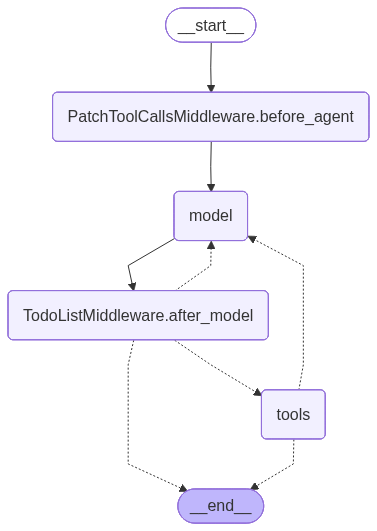

In [3]:

from src.agents.test import build_test_agent

agent = build_test_agent(backend=backend)

config = {
    "configurable": {
        "thread_id": "some_id"
    }
}

agent

After that, we can test the functionality by invoking it with the results of the comprehension_agent.

In [5]:
from langchain.messages import HumanMessage

prompt = (
    "Check if the transformation was successful. "
)

for chunk in agent.stream(
    input={
        "messages": [
            HumanMessage(content=prompt)
        ]
    },
    config=config,
    version="v2"
):
    logging.info(f"Agent response: {chunk}")

INFO:root:Agent response: {'type': 'updates', 'ns': (), 'data': {'PatchToolCallsMiddleware.before_agent': {'messages': Overwrite(value=[HumanMessage(content='Check if the transformation was successful. ', additional_kwargs={}, response_metadata={}, id='5299d3b8-bcfb-437c-a5fb-2e1c35d6c2f8'), AIMessage(content='<think>The user wants me to check if a transformation was successful. I should use the `read_transformation_plan` tool to read the transformation plan and understand what was expected to be created, then verify if those files exist.\n</think>\n\n\n', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 6919, 'total_tokens': 6981, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'lisa-code', 'system_fingerprint': None, 'id': 'chatcmpl-4f71f4c4-7388-93b2-9524-0ca96e337546', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e1be7-81aa-7410-8c65-a94a